<center>
<h1>COMP3242/6242: Deep Learning</h1>
<h2>Lab 12: Graph Neural Networks (and a bridge to Transformers)</h2>
Semester 1, 2026<br>
</center>

**Due**: 11:59pm on Sunday 31 May, 2026.<br>

Submit solutions as a single Jupyter Notebook via Canvas. Make sure that your name and student ID appears in the section below. You may not work with any other person in completing this laboratory. You must acknowledge any non-course texts or online material used. See the course policy on the use of generative AI tools such as ChatGPT and Claude.

This assignment will be **automatically graded**. Read and follow instructions carefully!

Test code is provided for you to check your work as you progress through the assignment. Feel free to add further tests and output useful for your own debugging but make sure to wrap these in an ``if is_notebook:`` conditional so that it does not run when we automatically grade your submission. We will exercise your code beyond what is provided here. Do not add any Jupyter notebook magic commands (i.e., those starting with `%` or `%%`). These may cause the autograding script to fail.

Complete all **TODOs** and delete any placeholder (`pass` and `...`).

This is the **last tutorial of the semester**! Tasks 1-5 are graded as usual. Section 6 is an open-ended research playground: it is **not** graded, but we strongly encourage you to play with it.

**Run all code blocks from start to end (`Restart & Run All`) and then save your Jupyter Notebook before submitting your assignment to ensure everything works as expected.**

*Acknowledgement: this lab and its accompanying slides are inspired by Petar Veličković's lecture at the Machine Learning Summer School 2026 (Melbourne), which several of the tutors attended.*

In [1]:
student_name = "Weiyi Jiang"
student_id = "u8191809"

In [2]:
import sys
import getpass

def is_notebook():
    return 'ipykernel' in sys.modules

import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import networkx as nx

from typing import Optional, Type

print("User: {} ({}, {})".format(getpass.getuser(), student_name, student_id))
print("Python Version: {}".format(sys.version))
print("PyTorch Version: {}".format(torch.__version__))

User: cichlidfish (Weiyi Jiang, u8191809)
Python Version: 3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:11:29) [Clang 20.1.8 ]
PyTorch Version: 2.10.0


### 1. Why a special architecture for graphs?

Up to this point in the course almost every architecture we have built has assumed
its input is either a vector ($\mathrm{MLP}$), a sequence
($\mathrm{RNN}$, $\mathrm{Transformer}$), or a grid ($\mathrm{CNN}$). A vast amount
of real-world data is not shaped like any of these. To name a few:

- molecules and proteins (atoms = nodes, bonds = edges) - drug discovery (e.g. Halicin, Abaucin), AlphaFold, ...;
- citation, social, traffic, knowledge and transaction networks;
- recommender systems (Pinterest's PinSage, Uber Eats, Amazon P-Companion, Spotify ...);
- and even abstract combinatorial objects (e.g. the Bruhat graph of permutations,
  whose study with GNNs hinted at a proof of the combinatorial invariance
  conjecture for Kazhdan-Lusztig polynomials).

If you have ever sent a message, ordered food online or looked up a paper recently, you
have almost certainly interacted with a Graph Neural Network (GNN).

So how should we design a neural network for a graph?

### Graphs and the ordering problem

A graph $G = (V, E)$ with $n = |V|$ nodes and $k$-dimensional node features can be
represented as a pair $(\mathbf{X}, \mathbf{A})$ where:

- $\mathbf{X} \in \mathbb{R}^{n \times k}$ stacks the node features row-wise;
- $\mathbf{A} \in \{0, 1\}^{n \times n}$ is the (binary, symmetric, for undirected
  graphs) adjacency matrix.

But this representation is *not unique*: the moment we wrote $\mathbf{X}$ down as a
matrix we had to **choose an ordering** of the nodes, and the choice was completely
arbitrary. If $\mathbf{P}$ is any $n \times n$ permutation matrix, then $(\mathbf{P}\mathbf{X}, \mathbf{P}\mathbf{A}\mathbf{P}^\top)$
describes *exactly the same graph*, just with a different node labelling.

This is the central design constraint for GNNs. Let $f$ be a neural network that takes
a graph and produces an output. We want $f$ to be one of:

| Task            | Symmetry condition                                                                                                | Example |
|-----------------|--------------------------------------------------------------------------------------------------------------------|---------|
| Graph-level     | **Invariance:**  $f(\mathbf{P}\mathbf{X}, \mathbf{P}\mathbf{A}\mathbf{P}^\top) = f(\mathbf{X}, \mathbf{A})$ | Predict a property of the whole molecule |
| Node-level      | **Equivariance:** $f(\mathbf{P}\mathbf{X}, \mathbf{P}\mathbf{A}\mathbf{P}^\top) = \mathbf{P}\, f(\mathbf{X}, \mathbf{A})$ | Predict a label for each user in a social network |
| Edge-level      | $f(\mathbf{P}\mathbf{X}, \mathbf{P}\mathbf{A}\mathbf{P}^\top) = \mathbf{P}\, f(\mathbf{X}, \mathbf{A})\, \mathbf{P}^\top$ | Predict if there should be a link |

This lab is about *node-level* tasks, so we want **equivariance**.

A naive baseline - flattening $\mathbf{X}$ to a vector and pushing it through an MLP -
violates this: changing the node ordering would change the output in unpredictable
ways. We will see this fail concretely in a moment, and then fix it.

### A universal recipe: equivariance through locality

A clean way to satisfy node-level equivariance is to make each layer act
**locally on each node and its neighbourhood**. For node $u$ with feature
$\mathbf{x}_u$ and neighbourhood $\mathcal{N}_u = \{v : \mathbf{A}_{uv} = 1\}$,
a one-layer GNN computes

$$\mathbf{h}_u \;=\; \phi\!\left(\mathbf{x}_u,\;\bigoplus_{v \in \mathcal{N}_u} \psi(\mathbf{x}_u, \mathbf{x}_v)\right),$$

where:

- $\psi$ is a **message function** that computes "what node $v$ wants to tell node $u$";
- $\bigoplus$ is a **permutation-invariant** aggregator (sum, mean, max ...);
- $\phi$ is an **update function** that combines $\mathbf{x}_u$ with the aggregated message.

Because the aggregator is permutation-invariant *over the neighbours of $u$*, the layer
as a whole is permutation-equivariant over the nodes. This is the unifying blueprint
behind essentially every GNN you will read about. By specialising $\psi$ and $\phi$ we
get three nested flavours (Bronstein et al., 2021):

| Flavour | Message $\psi(\mathbf{x}_u, \mathbf{x}_v)$ | What it is | Example |
|---|---|---|---|
| **Convolutional** $\subset$ | $c_{uv}\, \mathbf{x}_v$, $c_{uv}$ fixed by the graph | Linear filter, weights are a function of structure | GCN (Kipf & Welling, 2017) |
| **Attentional**   $\subset$ | $\alpha(\mathbf{x}_u, \mathbf{x}_v)\, \mathbf{x}_v$, $\alpha$ learned | Weighted by *learned*, *feature-dependent* coefficients | GAT (Veličković et al., 2018) |
| **Message-passing**        | arbitrary MLP of $(\mathbf{x}_u, \mathbf{x}_v)$ | Fully general | MPNN (Gilmer et al., 2017) |

We will implement one example of each flavour and check that they really are
equivariant. We will then circle back and discover, perhaps unexpectedly, that
**Transformers are an instance of the attentional flavour** applied to the
fully-connected graph.

### 2. Graphs in PyTorch, and permutation symmetry by example

We will work entirely with **dense** $(\mathbf{X}, \mathbf{A})$ tensors throughout
this lab - no graph libraries inside the model. Every operation is a `torch.matmul`,
a broadcast, or a softmax. This keeps the maths visible. We use `networkx` only for
plotting and for computing diagnostic quantities like graph diameter; the model
itself never sees it.

Let's build a small toy graph - the classic "house" graph on 6 nodes - and visualise it.

In [3]:
def make_house_graph():
    """A small undirected graph on 6 nodes with 3-dim random node features."""
    edges = [(0, 1), (1, 2), (2, 3), (3, 0), (0, 4), (1, 4), (2, 5), (3, 5), (4, 5)]
    n = 6
    A = torch.zeros(n, n)
    for (u, v) in edges:
        A[u, v] = 1.0
        A[v, u] = 1.0
    torch.manual_seed(0)
    X = torch.randn(n, 3)
    return X, A

X_house, A_house = make_house_graph()
print("X.shape =", tuple(X_house.shape))
print("A.shape =", tuple(A_house.shape))
print("A (symmetric, no self-loops):")
print(A_house.int().numpy())

X.shape = (6, 3)
A.shape = (6, 6)
A (symmetric, no self-loops):
[[0 1 0 1 1 0]
 [1 0 1 0 1 0]
 [0 1 0 1 0 1]
 [1 0 1 0 0 1]
 [1 1 0 0 0 1]
 [0 0 1 1 1 0]]


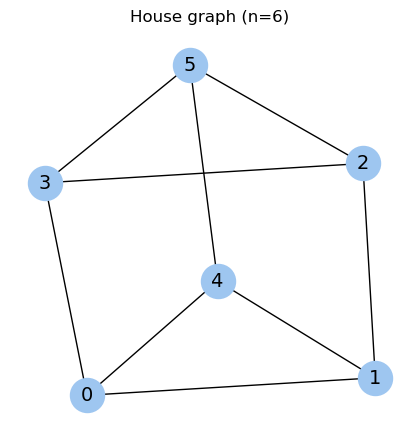

In [4]:
if is_notebook():
    G = nx.from_numpy_array(A_house.numpy())
    pos = nx.spring_layout(G, seed=2)
    plt.figure(figsize=(4, 4))
    nx.draw(G, pos, with_labels=True, node_color="#9ec6f0", node_size=600, font_size=14)
    plt.title("House graph (n=6)")
    plt.show()

### Task 1 - Build a permutation matrix

A permutation matrix $\mathbf{P} \in \{0, 1\}^{n \times n}$ is a square binary
matrix with exactly one $1$ in each row and each column. If `perm` is a Python list
of length $n$ representing a permutation of $\{0, 1, \ldots, n-1\}$, the
corresponding permutation matrix is the matrix that satisfies

$$\mathbf{P}_{i,\, \text{perm}[i]} = 1, \qquad \text{all other entries } 0.$$

Multiplying $\mathbf{P}$ on the left of a column vector $\mathbf{x}$ moves the entry
at position $\text{perm}[i]$ to position $i$:

$$(\mathbf{P}\mathbf{x})_i \;=\; \sum_j \mathbf{P}_{ij}\, \mathbf{x}_j \;=\; \mathbf{x}_{\text{perm}[i]}.$$

Applied row-wise to a matrix of node features $\mathbf{X}$, it reorders the nodes;
sandwiched as $\mathbf{P} \mathbf{A} \mathbf{P}^\top$, it reorders the adjacency
consistently.

Implement `make_permutation_matrix(perm)` returning a `float32` tensor of shape `(n, n)`.

*Hint*: torch has a function `torch.eye(n)` that returns the $n\times n$ identity matrix.
Indexing its rows by a permutation list does the rest.

In [5]:
def make_permutation_matrix(perm):
    """Return the (n, n) permutation matrix corresponding to the list `perm`."""
    perm = torch.as_tensor(perm, dtype=torch.long)
    n = perm.numel()
    return torch.eye(n, dtype=torch.float32, device=perm.device)[perm]

In [6]:
if is_notebook():
    perm = [2, 0, 3, 1]
    P = make_permutation_matrix(perm)
    assert P.shape == (4, 4), f"expected (4, 4), got {tuple(P.shape)}"
    assert torch.allclose(P.sum(dim=0), torch.ones(4)), "columns must sum to 1"
    assert torch.allclose(P.sum(dim=1), torch.ones(4)), "rows must sum to 1"
    assert torch.allclose(P @ P.T, torch.eye(4)), "P P^T must be identity"

    # Acts as expected on a vector.
    x = torch.tensor([10.0, 20.0, 30.0, 40.0])
    expected = torch.tensor([30.0, 10.0, 40.0, 20.0])  # x[perm[i]]
    assert torch.allclose(P @ x, expected), f"P @ x wrong: got {P @ x.tolist()}"

    # Acts as expected on an adjacency.
    Atest = torch.tensor([[0., 1, 0, 0], [1, 0, 1, 0], [0, 1, 0, 1], [0, 0, 1, 0]])
    Aperm = P @ Atest @ P.T
    # row/col perm[i] of Atest should be row/col i of Aperm
    for i in range(4):
        for j in range(4):
            assert Aperm[i, j] == Atest[perm[i], perm[j]]
    print("Task 1: make_permutation_matrix passed all checks.")

Task 1: make_permutation_matrix passed all checks.


### A reusable equivariance test

A node-level GNN layer $f(\mathbf{X}, \mathbf{A})$ is **permutation-equivariant** if for any
permutation matrix $\mathbf{P}$

$$f(\mathbf{P}\mathbf{X}, \mathbf{P}\mathbf{A}\mathbf{P}^\top) \;=\; \mathbf{P}\, f(\mathbf{X}, \mathbf{A}).$$

Equivalently, *relabelling the nodes first and then applying $f$ gives the same answer
as applying $f$ first and then relabelling*. The helper below checks this numerically.
We will reuse it for every layer in the rest of the lab.

In [7]:
def is_equivariant(layer, X, A, perm, atol=1e-5):
    """Numerically check whether `layer(X, A)` is permutation-equivariant under `perm`."""
    P = make_permutation_matrix(perm)
    out = layer(X, A)
    out_perm = layer(P @ X, P @ A @ P.T)
    return torch.allclose(P @ out, out_perm, atol=atol)

### Task 2 - A naive baseline: `FlattenedMLP`

The most obvious "deep learning" baseline for an $n \times k$ matrix of node
features is to flatten it to an $nk$-dimensional vector, push it through an MLP,
and reshape back. Implement this.

The architecture is simply:
```
flatten (n, k) -> (n*k,)
Linear(n*k -> n*k) -> ReLU -> Linear(n*k -> n*k)
reshape (n*k,) -> (n, k)
```

Notice that the input dimension depends on $n$, so this model can only ever be applied
to graphs of *one fixed size*. Already a problem- real GNNs work on any size. But
the bigger problem is that **it is not equivariant**: the second test cell below
will show $f(\mathbf{P}\mathbf{X}, \mathbf{P}\mathbf{A}\mathbf{P}^\top) \ne \mathbf{P}\, f(\mathbf{X}, \mathbf{A})$.
This is what motivates the rest of the lab.

In [8]:
class FlattenedMLP(nn.Module):
    """Treat (n, k) features as a vector of length n*k and run an MLP. Not equivariant."""

    def __init__(self, n: int, k: int) -> None:
        super().__init__()
        self.n = n
        self.k = k
        self.net = nn.Sequential(
            nn.Linear(n * k, n * k),
            nn.ReLU(),
            nn.Linear(n * k, n * k),
        )

    def forward(self, X: torch.Tensor, A: torch.Tensor) -> torch.Tensor:
        x = X.reshape(-1)
        out = self.net(x)
        return out.reshape(self.n, self.k)

In [9]:
if is_notebook():
    torch.manual_seed(0)
    n, k = 6, 3
    flat = FlattenedMLP(n, k)
    out = flat(X_house, A_house)
    assert out.shape == (n, k), f"expected (n, k) = ({n}, {k}), got {tuple(out.shape)}"
    print(f"FlattenedMLP forward OK, output shape = {tuple(out.shape)}")

    # A random permutation of the node ordering changes the output
    # in a way that is NOT just a row permutation. We expect this test to fail.
    torch.manual_seed(0)
    perm = torch.randperm(n).tolist()
    ok = is_equivariant(flat, X_house, A_house, perm)
    assert not ok, (
        "FlattenedMLP was unexpectedly equivariant. Did you accidentally write a "
        "GNN-style layer? Re-read the task."
    )
    print("FlattenedMLP is NOT permutation-equivariant - as expected. Time to fix that.")

FlattenedMLP forward OK, output shape = (6, 3)
FlattenedMLP is NOT permutation-equivariant - as expected. Time to fix that.


### 3. Implementing the three flavours of GNN

We now implement one layer of each flavour, all with the **same signature**:

```python
layer(X, A) -> X_new
```

where `X` is `(n, in_dim)`, `A` is the binary `(n, n)` adjacency, and `X_new` is
`(n, out_dim)`. After each implementation we run `is_equivariant` on the house graph
under a random permutation - they should all pass.

### Task 3 - GCN: a convolutional GNN

The Graph Convolutional Network (Kipf & Welling, ICLR 2017) sets

$$\mathbf{X}' \;=\; \sigma\!\left(\tilde{\mathbf{D}}^{-1/2}\,\tilde{\mathbf{A}}\,\tilde{\mathbf{D}}^{-1/2}\, \mathbf{X}\, \mathbf{W}\right),$$

where $\tilde{\mathbf{A}} = \mathbf{A} + \mathbf{I}$ adds self-loops, $\tilde{\mathbf{D}}$ is
the diagonal degree matrix of $\tilde{\mathbf{A}}$, and $\mathbf{W} \in \mathbb{R}^{\text{in\_dim}\times\text{out\_dim}}$
is a learnable weight matrix. We omit the activation $\sigma$ from the layer itself
(it lives outside, between stacked layers).

This is the *convolutional* flavour: the message is simply a fixed coefficient
$c_{uv} = (\tilde D_u \tilde D_v)^{-1/2}$ - determined entirely by the graph
structure - times the neighbour's transformed feature.

Implement `GCNLayer.forward(X, A)`.

In [10]:
class GCNLayer(nn.Module):
    """Symmetric-normalised graph convolution (Kipf & Welling, 2017)."""

    def __init__(self, in_dim: int, out_dim: int) -> None:
        super().__init__()
        self.lin = nn.Linear(in_dim, out_dim, bias=False)

    def forward(self, X: torch.Tensor, A: torch.Tensor) -> torch.Tensor:
        n = A.shape[0]
        A_self = A + torch.eye(n, device=A.device, dtype=A.dtype)
        deg = A_self.sum(dim=1)
        deg_inv_sqrt = deg.pow(-0.5)
        A_norm = deg_inv_sqrt.unsqueeze(1) * A_self * deg_inv_sqrt.unsqueeze(0)
        return A_norm @ self.lin(X)


In [11]:
if is_notebook():
    torch.manual_seed(0)
    gcn = GCNLayer(in_dim=3, out_dim=4)
    out = gcn(X_house, A_house)
    assert out.shape == (6, 4), f"expected (6, 4), got {tuple(out.shape)}"
    print(f"GCNLayer forward OK, shape = {tuple(out.shape)}")

    torch.manual_seed(1)
    perm = torch.randperm(6).tolist()
    assert is_equivariant(gcn, X_house, A_house, perm), "GCNLayer is not equivariant"
    print("GCNLayer is permutation-equivariant.")

GCNLayer forward OK, shape = (6, 4)
GCNLayer is permutation-equivariant.


### Task 4 - GAT: an attentional GNN

GCN gives every neighbour a fixed weight that depends only on graph structure
$(c_{uv} = (\tilde D_u \tilde D_v)^{-1/2})$. The Graph Attention Network
(Veličković et al., ICLR 2018) lets the weight **depend on the features** of the
two nodes:

$$\mathbf{h}_u \;=\; \sum_{v \in \mathcal{N}_u \cup \{u\}} \alpha_{uv}\, \mathbf{W} \mathbf{x}_v,
\qquad \alpha_{uv} = \mathrm{softmax}_v\!\big(e_{uv}\big), \qquad
e_{uv} = \mathrm{LeakyReLU}\!\big(\mathbf{a}^\top [\mathbf{W} \mathbf{x}_u \,\|\, \mathbf{W} \mathbf{x}_v]\big).$$

In words:

1. Project each node: $\mathbf{z}_u = \mathbf{W} \mathbf{x}_u$.
2. For every (ordered) pair of nodes $(u, v)$, form the concatenation $[\mathbf{z}_u\|\mathbf{z}_v]$
   and pass it through a learnable vector $\mathbf{a}$ followed by LeakyReLU. This is
   the raw attention logit $e_{uv}$.
3. **Mask** $e_{uv}$ to $-\infty$ wherever $\tilde{\mathbf{A}}_{uv} = 0$ (we add
   self-loops so each node attends to itself).
4. Softmax over $v$ (the neighbour axis) to get $\alpha_{uv}$.
5. Aggregate: $\mathbf{h}_u = \sum_v \alpha_{uv} \mathbf{z}_v$.


In [12]:
class GATLayer(nn.Module):
    """Graph Attention Network layer (single-head). Veličković et al., 2018."""

    def __init__(self, in_dim: int, out_dim: int, negative_slope: float = 0.2) -> None:
        super().__init__()
        self.out_dim = out_dim
        self.negative_slope = negative_slope
        self.lin = nn.Linear(in_dim, out_dim, bias=False)
        # a in R^{2*out_dim}; kept as a Linear(2*out_dim, 1) for nicer broadcasting.
        self.attn = nn.Linear(2 * out_dim, 1, bias=False)

    def forward(self, X: torch.Tensor, A: torch.Tensor) -> torch.Tensor:
        n = A.shape[0]
        A_self = A + torch.eye(n, device=A.device, dtype=A.dtype)
        z = self.lin(X)
        z_i = z.unsqueeze(1).expand(n, n, self.out_dim)
        z_j = z.unsqueeze(0).expand(n, n, self.out_dim)
        pair = torch.cat([z_i, z_j], dim=-1)
        logits = F.leaky_relu(self.attn(pair).squeeze(-1), self.negative_slope)
        logits = logits.masked_fill(A_self == 0, float("-inf"))
        alpha = F.softmax(logits, dim=-1)
        return alpha @ z

    @torch.no_grad()
    def attention_matrix(self, X: torch.Tensor, A: torch.Tensor) -> torch.Tensor:
        """Return the (n, n) attention coefficients alpha for inspection.
        Used only by the visualisation cell below; you do not have to modify it."""
        n = A.shape[0]
        A_self = A + torch.eye(n, device=A.device, dtype=A.dtype)
        z = self.lin(X)
        z_i = z.unsqueeze(1).expand(n, n, self.out_dim)
        z_j = z.unsqueeze(0).expand(n, n, self.out_dim)
        pair = torch.cat([z_i, z_j], dim=-1)
        logits = F.leaky_relu(self.attn(pair).squeeze(-1), self.negative_slope)
        logits = logits.masked_fill(A_self == 0, float("-inf"))
        return F.softmax(logits, dim=-1)


In [13]:
if is_notebook():
    torch.manual_seed(0)
    gat = GATLayer(in_dim=3, out_dim=4)
    out = gat(X_house, A_house)
    assert out.shape == (6, 4), f"expected (6, 4), got {tuple(out.shape)}"

    # The attention matrix should have zero mass on non-edges.
    alpha = gat.attention_matrix(X_house, A_house)
    A_self = A_house + torch.eye(6)
    assert torch.allclose(alpha[A_self == 0], torch.zeros_like(alpha[A_self == 0])), \
        "attention put mass on non-edges - check the masking step"
    # Rows should sum to 1.
    assert torch.allclose(alpha.sum(dim=-1), torch.ones(6), atol=1e-5), "alpha rows must sum to 1"
    print("GATLayer forward OK, attention is correctly masked and normalised.")

    torch.manual_seed(1)
    perm = torch.randperm(6).tolist()
    assert is_equivariant(gat, X_house, A_house, perm), "GATLayer is not equivariant"
    print("GATLayer is permutation-equivariant.")

GATLayer forward OK, attention is correctly masked and normalised.
GATLayer is permutation-equivariant.


### Task 5 - MPNN: a general message-passing GNN

Both GCN and GAT have a restrictive message form $\psi(\mathbf{x}_u, \mathbf{x}_v) = c_{uv}\, \mathbf{x}_v$
- the only thing that varies between flavours is *how* the coefficient $c_{uv}$ is chosen.
A general Message-Passing Neural Network (Gilmer et al., 2017) drops this restriction.
The message is an **arbitrary MLP** of the pair $(\mathbf{x}_u, \mathbf{x}_v)$:

$$\mathbf{m}_{uv} = \psi\!\big([\mathbf{x}_u \,\|\, \mathbf{x}_v]\big),\qquad
\mathbf{a}_u = \sum_{v \in \mathcal{N}_u} \mathbf{m}_{uv},\qquad
\mathbf{h}_u = \phi\!\big([\mathbf{x}_u \,\|\, \mathbf{a}_u]\big).$$

Implement this. The two MLPs $\psi$ and $\phi$ have already been built in `__init__`.
The constructor signature is `MPNNLayer(in_dim, out_dim, msg_dim=16)` - we keep
`out_dim` as the second positional argument so the same `GNN` stacking code from
Task 6 will work uniformly across all three flavours. You only need to fill in
`forward`:

1. Build the pairwise feature tensor `pair` of shape `(n, n, 2*in_dim)`, where
   `pair[u, v] = cat([X[u], X[v]])`.
2. Apply `self.psi` in parallel to get messages `M` of shape `(n, n, msg_dim)`.
3. Mask non-edges to zero (multiply by `A.unsqueeze(-1)`) and sum over `dim=1`
   to get aggregated messages `agg` of shape `(n, msg_dim)`.
4. Concatenate `[X, agg]` along the feature axis and apply `self.phi` to get
   the output of shape `(n, out_dim)`.

In [14]:
class MPNNLayer(nn.Module):
    """General message-passing GNN with learnable message and update functions.

    Note the signature - to remain compatible with the generic GNN classifier in
    Task 6, the second positional argument is `out_dim`, with `msg_dim` as a
    keyword argument.
    """

    def __init__(self, in_dim: int, out_dim: int, msg_dim: int = 16) -> None:
        super().__init__()
        self.in_dim = in_dim
        self.msg_dim = msg_dim
        self.out_dim = out_dim
        # psi: message MLP, takes [x_u || x_v] -> message of size msg_dim.
        self.psi = nn.Sequential(
            nn.Linear(2 * in_dim, msg_dim),
            nn.ReLU(),
            nn.Linear(msg_dim, msg_dim),
        )
        # phi: update MLP, takes [x_u || agg_u] -> new feature of size out_dim.
        self.phi = nn.Sequential(
            nn.Linear(in_dim + msg_dim, out_dim),
            nn.ReLU(),
            nn.Linear(out_dim, out_dim),
        )

    def forward(self, X: torch.Tensor, A: torch.Tensor) -> torch.Tensor:
        n = X.shape[0]
        x_i = X.unsqueeze(1).expand(n, n, self.in_dim)
        x_j = X.unsqueeze(0).expand(n, n, self.in_dim)
        pair = torch.cat([x_i, x_j], dim=-1)
        M = self.psi(pair)
        agg = (M * A.unsqueeze(-1)).sum(dim=1)
        return self.phi(torch.cat([X, agg], dim=-1))


In [15]:
if is_notebook():
    torch.manual_seed(0)
    mpnn = MPNNLayer(in_dim=3, out_dim=4, msg_dim=8)
    out = mpnn(X_house, A_house)
    assert out.shape == (6, 4), f"expected (6, 4), got {tuple(out.shape)}"
    print(f"MPNNLayer forward OK, shape = {tuple(out.shape)}")

    torch.manual_seed(1)
    perm = torch.randperm(6).tolist()
    assert is_equivariant(mpnn, X_house, A_house, perm), "MPNNLayer is not equivariant"
    print("MPNNLayer is permutation-equivariant.")

MPNNLayer forward OK, shape = (6, 4)
MPNNLayer is permutation-equivariant.


### 4. A real task: node classification on a stochastic block model

Time to actually train these layers. We will use a **Stochastic Block Model (SBM)**:
nodes split into $C$ communities, with within-community edge probability $p_\text{in}$
and between-community probability $p_\text{out} < p_\text{in}$. The label of each node
is its community ID. Node features are a noisy one-hot encoding of the community, so
some information is in the features themselves but the graph structure is *also*
informative.

This is a clean, controlled benchmark: there is no train/test split issue, no dataset
download, and we can sweep over `signal`, `noise`, `p_in`, `p_out` to see when each
flavour wins.

In [16]:
def make_sbm(
    n_per_block: int = 20,
    n_blocks: int = 4,
    p_in: float = 0.3,
    p_out: float = 0.02,
    feat_dim: int = 8,
    signal: float = 1.0,
    noise: float = 0.5,
    seed: int = 0,
):
    """Build a small SBM graph with noisy one-hot community features."""
    torch.manual_seed(seed)
    n = n_per_block * n_blocks
    y = torch.arange(n_blocks).repeat_interleave(n_per_block)

    # Random adjacency given block membership.
    same_block = y.unsqueeze(0) == y.unsqueeze(1)
    p = torch.where(same_block, torch.tensor(p_in), torch.tensor(p_out))
    A = (torch.rand(n, n) < p).float()
    A = torch.triu(A, diagonal=1)
    A = A + A.T  # symmetric, no self-loops

    # Noisy one-hot community features, padded out to feat_dim.
    onehot = F.one_hot(y, num_classes=n_blocks).float()
    if feat_dim > n_blocks:
        onehot = F.pad(onehot, (0, feat_dim - n_blocks))
    X = signal * onehot + noise * torch.randn(n, feat_dim)

    # 60/40 train/test split.
    perm = torch.randperm(n)
    n_train = int(0.6 * n)
    train_mask = torch.zeros(n, dtype=torch.bool)
    train_mask[perm[:n_train]] = True
    test_mask = ~train_mask

    return X, A, y, train_mask, test_mask

SBM has n = 80 nodes, 273 undirected edges, 4 communities.


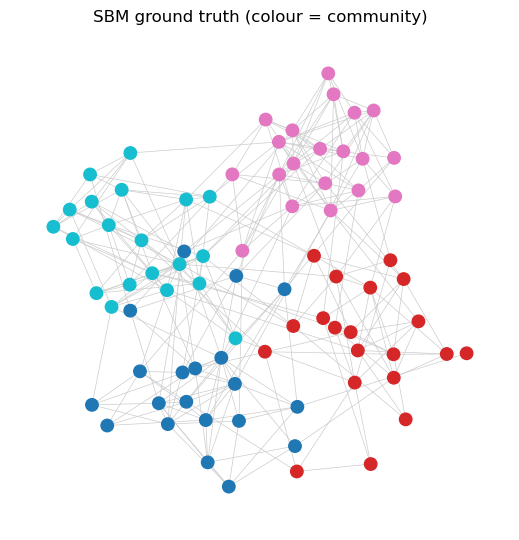

In [17]:
if is_notebook():
    X_sbm, A_sbm, y_sbm, train_mask, test_mask = make_sbm(seed=0)
    n = X_sbm.shape[0]
    print(f"SBM has n = {n} nodes, {int(A_sbm.sum().item() / 2)} undirected edges, "
          f"{int(y_sbm.max().item()) + 1} communities.")

    G = nx.from_numpy_array(A_sbm.numpy())
    pos = nx.spring_layout(G, seed=2, k=0.4)
    plt.figure(figsize=(5, 5))
    nx.draw(G, pos, node_color=y_sbm.numpy(), cmap="tab10",
            node_size=80, with_labels=False, edge_color="#cccccc", width=0.5)
    plt.title("SBM ground truth (colour = community)")
    plt.show()

### Task 6 - Stack layers into a `GNN` classifier

A node classifier built on top of any of our three layers has the same shape:

1. A first GNN layer mapping `(n, in_dim) -> (n, hidden)`.
2. A ReLU non-linearity (applied node-wise).
3. A second GNN layer mapping `(n, hidden) -> (n, hidden)`.
4. A ReLU.
5. A final `Linear(hidden -> n_classes)` (applied node-wise, no aggregation).

Implement this as a generic `GNN(layer_cls, in_dim, hidden, n_classes, **layer_kwargs)`
where `layer_cls` is one of `GCNLayer`, `GATLayer`, `MPNNLayer`. **Important**: pass
`**layer_kwargs` through to the two GNN layers - this is needed so `MPNNLayer` can
receive its `msg_dim` argument.

All three layer classes share the same constructor convention
`layer_cls(...)`, so the same single call
`layer_cls(...)` works for all three. For `MPNNLayer`
the caller just passes `msg_dim=...` via `layer_kwargs` (see the test cell).

In [18]:
class GNN(nn.Module):
    """Two-layer GNN classifier on top of any layer flavour."""

    def __init__(
        self,
        layer_cls: Type[nn.Module],
        in_dim: int,
        hidden: int,
        n_classes: int,
        **layer_kwargs,
    ) -> None:
        super().__init__()
        self.layer1 = layer_cls(in_dim, hidden, **layer_kwargs)
        self.layer2 = layer_cls(hidden, hidden, **layer_kwargs)
        self.head = nn.Linear(hidden, n_classes)

    def forward(self, X: torch.Tensor, A: torch.Tensor) -> torch.Tensor:
        X = F.relu(self.layer1(X, A))
        X = F.relu(self.layer2(X, A))
        return self.head(X)

In [19]:
if is_notebook():
    torch.manual_seed(0)
    in_dim, hidden, n_classes = 8, 16, 4
    n_test, k_test = 10, in_dim
    X_t = torch.randn(n_test, k_test)
    A_t = (torch.rand(n_test, n_test) < 0.3).float()
    A_t = torch.triu(A_t, 1); A_t = A_t + A_t.T

    for name, layer_cls, layer_kwargs in [
        ("GCN", GCNLayer, {}),
        ("GAT", GATLayer, {}),
        ("MPNN", MPNNLayer, {"msg_dim": 8}),
    ]:
        torch.manual_seed(0)
        model = GNN(layer_cls, in_dim, hidden, n_classes, **layer_kwargs)
        logits = model(X_t, A_t)
        assert logits.shape == (n_test, n_classes), \
            f"{name}: expected ({n_test}, {n_classes}), got {tuple(logits.shape)}"
        torch.manual_seed(2)
        perm = torch.randperm(n_test).tolist()
        assert is_equivariant(model, X_t, A_t, perm, atol=1e-4), \
            f"GNN({name}) is not equivariant"
        print(f"GNN({name}) forward + equivariance OK.")

GNN(GCN) forward + equivariance OK.
GNN(GAT) forward + equivariance OK.
GNN(MPNN) forward + equivariance OK.


### Training and comparison

Now we train one of each flavour on the SBM and compare. The training loop is
provided. Each model gets the same number of epochs and the same hyperparameters.

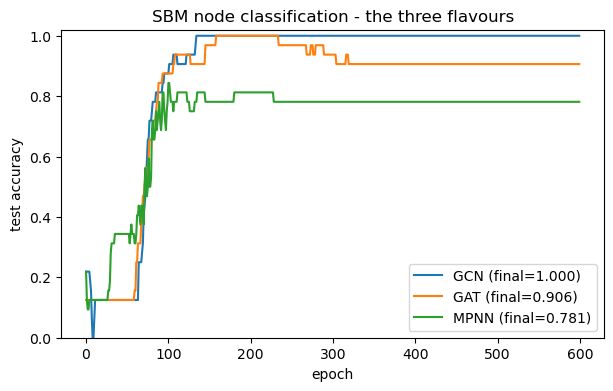

  GCN final test accuracy = 1.000
  GAT final test accuracy = 0.906
 MPNN final test accuracy = 0.781


In [20]:
def train_gnn(model, X, A, y, train_mask, test_mask, lr=2e-3, n_epochs=600):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    test_accs = []
    for epoch in range(n_epochs):
        model.train()
        logits = model(X, A)
        loss = F.cross_entropy(logits[train_mask], y[train_mask])
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        model.eval()
        with torch.no_grad():
            pred = model(X, A).argmax(dim=-1)
            test_accs.append((pred[test_mask] == y[test_mask]).float().mean().item())
    return test_accs

if is_notebook():
    torch.manual_seed(0)
    X_sbm, A_sbm, y_sbm, train_mask, test_mask = make_sbm(seed=0)
    in_dim, hidden, n_classes = X_sbm.shape[1], 16, int(y_sbm.max().item()) + 1
    curves = {}
    for name, layer_cls, kw in [
        ("GCN", GCNLayer, {}),
        ("GAT", GATLayer, {}),
        ("MPNN", MPNNLayer, {"msg_dim": 16}),
    ]:
        torch.manual_seed(0)
        model = GNN(layer_cls, in_dim, hidden, n_classes, **kw)
        curves[name] = train_gnn(model, X_sbm, A_sbm, y_sbm, train_mask, test_mask)
        # save the trained GAT for the visualisation cell below
        if name == "GAT":
            trained_gat_model = model

    plt.figure(figsize=(7, 4))
    for name, accs in curves.items():
        plt.plot(accs, label=f"{name} (final={accs[-1]:.3f})")
    plt.xlabel("epoch")
    plt.ylabel("test accuracy")
    plt.ylim(0, 1.02)
    plt.legend()
    plt.title("SBM node classification - the three flavours")
    plt.show()
    for name, accs in curves.items():
        print(f"{name:>5s} final test accuracy = {accs[-1]:.3f}")

### Bonus visualisation (not graded): does GAT learn the community structure?

If the attentional flavour is doing its job, the learned attention coefficients
$\alpha_{uv}$ should put more weight on edges *within* communities than across them
- effectively turning $\mathbf{A}$ into a softer, community-aware adjacency.

We plot the learned attention matrix of the first GAT layer side-by-side with the
ground-truth SBM adjacency. Look for blockiness aligned with the community labels.

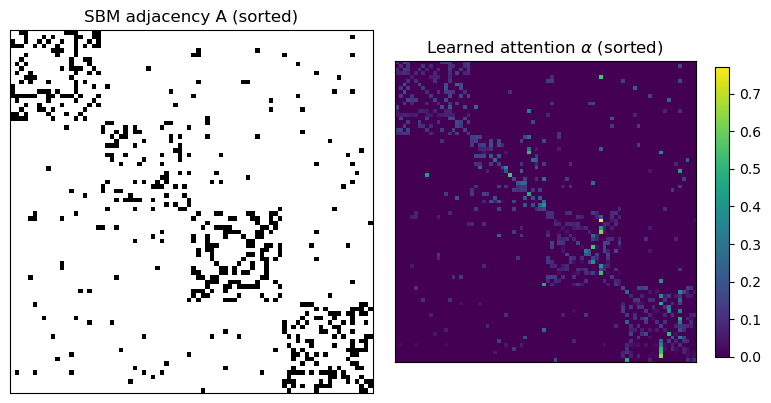

In [21]:
if is_notebook():
    layer = trained_gat_model.layer1
    alpha = layer.attention_matrix(X_sbm, A_sbm)

    # sort nodes by community so the SBM block structure is visible.
    order = torch.argsort(y_sbm)
    A_sorted = A_sbm[order][:, order]
    alpha_sorted = alpha[order][:, order]

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(A_sorted, cmap="Greys", interpolation="nearest")
    axes[0].set_title("SBM adjacency A (sorted)")
    axes[0].set_xticks([]); axes[0].set_yticks([])
    im = axes[1].imshow(alpha_sorted, cmap="viridis", interpolation="nearest")
    axes[1].set_title("Learned attention $\\alpha$ (sorted)")
    axes[1].set_xticks([]); axes[1].set_yticks([])
    plt.colorbar(im, ax=axes[1], shrink=0.8)
    plt.tight_layout(); plt.show()

### Things to poke at (optional)

Once you have the three curves above, try:

- Set `noise = 2.0` (or higher) in the call to `make_sbm`. The features become
  uninformative on their own - the GNN can recover only by using the graph
  structure. A model that ignored the graph would collapse to chance.
- Set `signal = 0.0` and `noise = 1.0`. Now *all* community information is in the
  graph. Watch how performance depends on how well the layer uses the structure.
- Replace `A` with `torch.eye(n)` in the call to `train_gnn`. Every GNN flavour now
  degenerates to a per-node MLP - so accuracy should drop to whatever a per-node
  classifier gets on the raw features. Confirms that the layers really are using
  the graph.

### 5. The bridge - Transformers are GNNs

We now connect everything to material you already know.

**Claim:** *self-attention is an attentional GNN on the fully-connected graph.*

Recall scaled dot-product self-attention from the lectures: given tokens $\mathbf{X} \in \mathbb{R}^{n \times d}$
and projection matrices $\mathbf{W}_Q, \mathbf{W}_K, \mathbf{W}_V$,

$$\mathrm{Attn}(\mathbf{X}) \;=\; \mathrm{softmax}\!\left(\frac{\mathbf{Q}\mathbf{K}^\top}{\sqrt{d_k}}\right)\mathbf{V}, \qquad \mathbf{Q} = \mathbf{X}\mathbf{W}_Q,\;\;\mathbf{K}=\mathbf{X}\mathbf{W}_K,\;\;\mathbf{V}=\mathbf{X}\mathbf{W}_V.$$

Compare this to the GAT update from Task 4:

$$\mathbf{h}_u \;=\; \sum_v \alpha_{uv}\, \mathbf{W}\mathbf{x}_v, \qquad \alpha_{uv} = \mathrm{softmax}_v(e_{uv}).$$

The two are the same recipe with three substitutions:

1. The attention mechanism $e_{uv}$ is changed from a learned MLP on
   $[\mathbf{W}\mathbf{x}_u\|\mathbf{W}\mathbf{x}_v]$ to a scaled dot product
   $\mathbf{q}_u^\top \mathbf{k}_v / \sqrt{d_k}$.
2. The value projection $\mathbf{V}$ is allowed to differ from the projection used
   inside the attention logit.
3. The graph $\mathbf{A}$ is the **fully-connected** graph $\mathbf{A} = \mathbf{1}\mathbf{1}^\top - \mathbf{I}$
   (or $\mathbf{1}\mathbf{1}^\top$ if you also let each token attend to itself).

We will now write a transformer-style self-attention block whose signature is the
same as our GNN layers: `forward(X, A)`. When `A` is the fully-connected graph it is
ordinary self-attention. When `A` is *any* binary mask it is **masked** self-attention
- which is exactly how causal LMs and graph-aware Transformers (Graphormer,
GraphGPS, ...) work.

### Task 7 - Self-attention as a GNN

Implement `SelfAttentionAsGNN(d_model, d_k)`:

- Three `nn.Linear` projections `W_q, W_k, W_v` mapping `d_model -> d_k` (so the
  output has the same dimension as the keys; for simplicity we let `d_v = d_k`).
- `forward(self, X, A=None)`:
  1. Compute `Q = self.W_q(X)`, `K = self.W_k(X)`, `V = self.W_v(X)`.
  2. Form logits.
  3. **If `A is not None`**: replace logit entries where `A == 0` with `-inf`,
     so the softmax assigns them probability zero. This is how the GNN-style mask
     enters - including causal masking (a lower-triangular `A`) and graph-aware
     attention.
  4. Compute `alpha` via softmax and return the multiplication `alpha V`.

Notice the signature `forward(X, A=None)` lets us call this layer like any other GNN
layer in our codebase. If a caller passes the fully-connected adjacency, the result
is ordinary self-attention; if a caller passes a sparse $\mathbf{A}$, it is exactly
a single-head scaled-dot-product GAT variant.

In [22]:
class SelfAttentionAsGNN(nn.Module):
    """Single-head scaled dot-product attention with an optional adjacency mask.

    When A is None or the fully-connected adjacency, this is ordinary self-attention.
    With a binary mask A, only positions with A[u, v] = 1 contribute to head u.
    """

    def __init__(self, d_model: int, d_k: int) -> None:
        super().__init__()
        self.d_k = d_k
        self.W_q = nn.Linear(d_model, d_k, bias=False)
        self.W_k = nn.Linear(d_model, d_k, bias=False)
        self.W_v = nn.Linear(d_model, d_k, bias=False)

    def forward(self, X: torch.Tensor, A: Optional[torch.Tensor] = None) -> torch.Tensor:
        Q = self.W_q(X)
        K = self.W_k(X)
        V = self.W_v(X)
        logits = (Q @ K.T) / math.sqrt(self.d_k)
        if A is not None:
            logits = logits.masked_fill(A == 0, float("-inf"))
        alpha = F.softmax(logits, dim=-1)
        return alpha @ V

In [23]:
if is_notebook():
    torch.manual_seed(0)
    n, d_model, d_k = 8, 4, 5
    attn = SelfAttentionAsGNN(d_model, d_k)
    X_t = torch.randn(n, d_model)
    A_full = torch.ones(n, n)

    # Equivariance on the fully-connected graph (standard self-attention).
    torch.manual_seed(3)
    perm = torch.randperm(n).tolist()
    assert is_equivariant(lambda X, A: attn(X, A), X_t, A_full, perm, atol=1e-5), \
        "SelfAttentionAsGNN is not permutation-equivariant on the FC graph"
    print("SelfAttentionAsGNN is equivariant on the fully-connected graph.")

    # Calling with no A should equal calling with the all-ones A.
    out_no_mask = attn(X_t, None)
    out_full_mask = attn(X_t, A_full)
    assert torch.allclose(out_no_mask, out_full_mask, atol=1e-5), \
        "A=None should behave the same as A=all-ones"

    # Causal mask: a token at position i can only attend to positions <= i.
    A_causal = torch.tril(torch.ones(n, n))
    out_causal = attn(X_t, A_causal)
    assert out_causal.shape == (n, d_k)
    # The first row should equal W_v(X[0]) (single token attending only to itself).
    assert torch.allclose(out_causal[0], attn.W_v(X_t[:1]).squeeze(0), atol=1e-5), \
        "Causal-mask row 0 should attend only to position 0"
    print("SelfAttentionAsGNN respects the adjacency mask correctly.")

SelfAttentionAsGNN is equivariant on the fully-connected graph.
SelfAttentionAsGNN respects the adjacency mask correctly.


### Reading what we just did

Three things to notice:

- **Positional encodings inject a line graph through node features.** A pure Transformer
  on top of `(X, A_fully_connected)` cannot distinguish "the cat sat on the mat" from
  "mat the on sat cat the". Positional encodings (sinusoidal, learned, RoPE, ...) put
  position-dependent information *into* `X`, which acts like an edge feature on the
  implicit path graph $0 \to 1 \to \ldots \to (n-1)$.
- **Relative position encodings are edge features.** RPE adds a term that depends on
  $u - v$ inside the attention logit - exactly $\psi(\mathbf{x}_u, \mathbf{x}_v, \mathbf{e}_{uv})$
  in the MPNN template.
- **Causal masking is a directed line graph.** A causal attention mask sets $\alpha_{uv} = 0$
  whenever $v > u$ - a strict triangular adjacency. *The propagation graph of a GPT-style
  LLM is therefore a feedforward graph*. That fact will turn out to matter a lot in
  Section 6.

### 6. Exploration (not graded) - does the propagation graph matter?

You have now seen that every GNN, *and* every Transformer, is parameterised by a
choice of propagation graph $\mathbf{A}$. The interesting research question is:
**what is the best $\mathbf{A}$ for a given task?** This section is a sandbox - the
tests below are sanity checks, not autograded.

We will tackle one synthetic long-range task. Build a graph with $n$ nodes. Node 0
holds a binary label (say in its first feature dimension). The model has to output
that bit on node $n-1$. After $L$ GNN layers, this only works if information can
travel from node 0 to node $n-1$ in at most $L$ hops.

We try three propagation graphs:

| Graph | Diameter | Average degree | Expectation |
|---|---|---|---|
| Line graph $0 - 1 - \ldots - (n-1)$ | $n-1$ | 2 | should fail as $n$ grows: too many hops |
| Fully-connected $\mathbf{1}\mathbf{1}^\top - \mathbf{I}$ | 1 | $n-1$ | reach is trivial, but information disperses through the softmax |
| $d$-regular random expander | $O(\log n)$ | $d$ | mixes globally and keeps each node's neighbourhood small |

The expectations come from **over-squashing** (Alon & Yahav, ICLR 2021) - bottleneck
edges concentrate exponentially many paths into a single message - and from
**softmax dispersion** (Barbero et al., NeurIPS 2024) - that with growing $n$ the
maximum softmax weight in an attentional layer is provably bounded away from 1.
We will not reproduce those theorems here; the markdown discussion below points
to the papers. But you should observe the qualitative phenomena in the sweep
below.

In [24]:
def build_line_adj(n: int) -> torch.Tensor:
    """Undirected path graph 0 - 1 - 2 - ... - (n-1)."""
    A = torch.zeros(n, n)
    for i in range(n - 1):
        A[i, i + 1] = 1.0
        A[i + 1, i] = 1.0
    return A

def build_full_adj(n: int) -> torch.Tensor:
    """Fully-connected graph (no self-loops)."""
    return 1.0 - torch.eye(n)

def build_expander_adj(n: int, d: int = 3, seed: int = 0) -> torch.Tensor:
    """Random d-regular graph as a dense adjacency. d-regular random graphs are
    expanders with high probability."""
    if (n * d) % 2 != 0:
        d += 1  # n*d must be even
    G = nx.random_regular_graph(d, n, seed=seed)
    A = nx.to_numpy_array(G)
    return torch.from_numpy(A).float()

def _graph_diagnostics(A: torch.Tensor) -> tuple[int, int]:
    """Return (diameter, shortest_path 0 -> n-1) of a graph given as a dense adjacency."""
    G = nx.from_numpy_array(A.numpy())
    diam = nx.diameter(G) if nx.is_connected(G) else -1
    try:
        sp = nx.shortest_path_length(G, source=0, target=A.shape[0] - 1)
    except nx.NetworkXNoPath:
        sp = -1
    return diam, sp

if is_notebook():
    # We will train with a 2-layer GNN, so information can travel at most 2 hops.
    # The column "0 -> n-1" is the shortest source-to-target hop count: if it
    # exceeds 2, the model literally cannot see node 0's bit at node n-1.
    print(f"{'n':>3}  {'graph':>9}  {'diam':>4}  {'0 -> n-1':>9}  reachable in 2 layers?")
    for n in [8, 16, 32]:
        for name, A in [("line",     build_line_adj(n)),
                        ("full",     build_full_adj(n)),
                        ("expander", build_expander_adj(n, d=4, seed=0))]:
            diam, sp = _graph_diagnostics(A)
            reach = "YES" if 0 <= sp <= 2 else "no"
            print(f"{n:>3}  {name:>9}  {diam:>4}  {sp:>9}  {reach}")

  n      graph  diam   0 -> n-1  reachable in 2 layers?
  8       line     7          7  no
  8       full     1          1  YES
  8   expander     2          1  YES
 16       line    15         15  no
 16       full     1          1  YES
 16   expander     4          1  YES
 32       line    31         31  no
 32       full     1          1  YES
 32   expander     4          3  no


In [25]:
def make_long_range_examples(n: int, n_examples: int, feat_dim: int = 8, seed: int = 0):
    """Generate `n_examples` instances of the long-range copy task.

    On every instance the label is a single bit placed in feature 0 of node 0.
    Labels are **exactly balanced** (50/50) by construction, then shuffled, so a
    trivial constant-prediction baseline scores 50% rather than whatever class
    imbalance the random sampler happens to produce. All other features are
    i.i.d. noise drawn from a separate rng stream that is independent of the
    labels, so the model cannot memorise a spurious shortcut.
    """
    assert n_examples % 2 == 0, "n_examples must be even for exactly balanced labels"
    g_perm = torch.Generator().manual_seed(seed)
    g_noise = torch.Generator().manual_seed(seed + 10_000)

    labels = torch.cat([torch.zeros(n_examples // 2, dtype=torch.long),
                        torch.ones(n_examples // 2, dtype=torch.long)])
    labels = labels[torch.randperm(n_examples, generator=g_perm)]

    Xs = 0.1 * torch.randn(n_examples, n, feat_dim, generator=g_noise)
    Xs[:, 0, 0] = labels.float()  # overwrite node-0's first feature with the bit
    return Xs, labels

n =   8  line = 0.48  full = 0.84  expander = 0.91
n =  16  line = 0.53  full = 0.83  expander = 0.97
n =  32  line = 0.58  full = 0.75  expander = 0.56


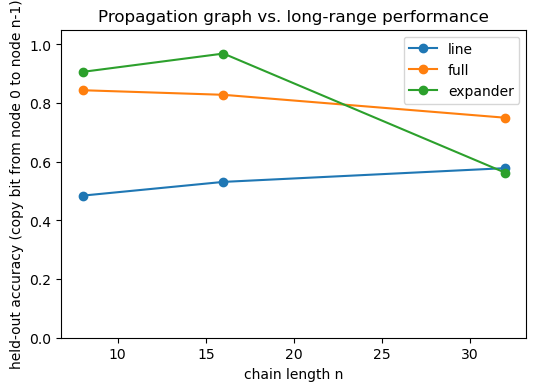

In [26]:
def train_long_range(layer_cls, A, n_steps=400, n_train=128, n_test=64,
                     hidden=32, lr=5e-3, **layer_kw):
    """Train a 2-layer GNN on a long-range bit-copy task. Returns *held-out* accuracy."""
    n = A.shape[0]
    Xs_tr, ys_tr = make_long_range_examples(n, n_train, seed=0)
    Xs_te, ys_te = make_long_range_examples(n, n_test, seed=12345)

    in_dim = Xs_tr.shape[-1]
    torch.manual_seed(0)
    model = GNN(layer_cls, in_dim, hidden, 2, **layer_kw)
    opt = optim.Adam(model.parameters(), lr=lr)

    for _ in range(n_steps):
        opt.zero_grad()
        loss = 0.0
        for b in range(n_train):
            logits = model(Xs_tr[b], A)              # (n, 2)
            loss = loss + F.cross_entropy(logits[-1:], ys_tr[b:b + 1])
        loss = loss / n_train
        loss.backward()
        opt.step()

    model.eval()
    correct = 0
    with torch.no_grad():
        for b in range(n_test):
            pred = model(Xs_te[b], A)[-1].argmax().item()
            correct += int(pred == ys_te[b].item())
    return correct / n_test

if is_notebook():
    ns = [8, 16, 32]
    results = {"line": [], "full": [], "expander": []}
    for n in ns:
        results["line"].append(
            train_long_range(GCNLayer, build_line_adj(n), n_steps=150)
        )
        results["full"].append(
            train_long_range(GCNLayer, build_full_adj(n), n_steps=150)
        )
        results["expander"].append(
            train_long_range(GCNLayer, build_expander_adj(n, d=4, seed=0), n_steps=150)
        )
        print(f"n = {n:3d}  line = {results['line'][-1]:.2f}  "
              f"full = {results['full'][-1]:.2f}  "
              f"expander = {results['expander'][-1]:.2f}")

    plt.figure(figsize=(6, 4))
    for name, accs in results.items():
        plt.plot(ns, accs, marker="o", label=name)
    plt.xlabel("chain length n")
    plt.ylabel("held-out accuracy (copy bit from node 0 to node n-1)")
    plt.ylim(0.0, 1.05)
    plt.legend()
    plt.title("Propagation graph vs. long-range performance")
    plt.show()

### What you are looking at

Some things you will probably observe (it is a small sweep with a tiny model and a
fixed seed - results will jitter):

- The **line** graph fails *immediately*, even at $n = 8$. The diagnostic table
  above tells us why: shortest path from node $0$ to node $n-1$ is $n-1$ hops,
  and our model only has two GNN layers. Information about node $0$'s bit
  simply never reaches the prediction node, so the model is stuck at chance
  ($\approx 0.5$). This is **under-reaching**. If we stacked many more layers
  to fix it we would instead start seeing **over-squashing**: exponentially
  many paths funnel through the same bottleneck nodes and get squeezed into a
  fixed-size message (Alon & Yahav, ICLR 2021).
- The **fully-connected** graph fixes reach (every node is one hop from every
  other), but its accuracy gently degrades as $n$ grows. The information from
  node $0$ is now averaged over $n - 1$ neighbours, so the relevant signal at
  node $n-1$ shrinks like $1/n$ - **dispersion**. The attentional version of
  this story is sharper still: with an attentional layer (try replacing
  `GCNLayer` with `GATLayer` in the sweep!) the max softmax weight on the
  *correct* neighbour is provably bounded away from $1$ as $n$ grows
  (Barbero et al., NeurIPS 2024).
- The **expander** wins until its own $0 \to (n-1)$ distance exceeds the model
  depth. At $n = 8, 16$ the relevant path is just $1$ hop in our particular
  seed, so the model has plenty of slack. At $n = 32$ the path is $3$ hops
  long, which is one more than our $2$ GNN layers can deliver - and the
  accuracy collapses to chance, just like the line graph. Expanders mix
  globally in $O(\log n)$ hops on average; on any single instance the actual
  source-to-target distance can still exceed the model depth.

These are the same phenomena studied in the GNN literature for years
(Expander Graph Propagation, Deac et al., LoG 2022). The recent realisation
is that they apply directly to **Transformers and LLMs** under the GNN view
of self-attention from Section 5 - feedforward LLM graphs are bottlenecked
in exactly the same way (Barbero et al., NeurIPS 2024; Vitvitskyi et al.,
ICML 2025).

### Open exercise 6.2 (ungraded)

Can you design a better propagation graph? Two or three to try:

- **Bipartite "router" graph.** Add a constant number of extra "super-nodes" that
  every real node connects to. Two hops then suffice to reach anywhere.
- **Log-jump (Watts-Strogatz-like) graph.** Keep the line graph but add an extra
  edge from node $i$ to node $i + 2^k$ for every valid $k$. Diameter drops from
  $n$ to $\log_2 n$ while average degree stays $O(\log n)$.
- **Small-world rewiring.** Start from a regular ring of degree $d$ and randomly
  rewire each edge with probability $p$. At small $p$ you keep local structure
  but slash the diameter.

Code one of these as a `build_my_adj(n)` function, rerun the sweep, and write a
3-5 sentence note on what you see and *why*. This exercise is **ungraded** -
it is here to give you something to play with.

### 7. Wrap-up

Four takeaways from this lab:

1. **Symmetry dictates architecture.** Once you accept that node ordering is
   arbitrary, every layer must commute with permutations. The cleanest way to
   enforce this is locality + an invariant aggregator. Every GNN you will ever
   meet is some specialisation of
   $h_u = \phi(x_u, \bigoplus_{v} \psi(x_u, x_v))$.
2. **Three flavours form a strict hierarchy.** *Convolutional $\subset$
   Attentional $\subset$ Message-passing*. Use the simplest one that works;
   reach for MPNN only when you genuinely need edge-conditional messages.
3. **Transformers are GNNs.** Self-attention is the attentional flavour on the
   fully-connected graph; positional encodings inject the line graph through
   features; causal masking restricts the graph to a feedforward DAG.
4. **The graph itself is a hyperparameter.** The same model can succeed on one
   propagation graph and fail on another - over-squashing on bottlenecks,
   dispersion on dense ones. Rewiring (GDC, SDRF, EGP, expander templates) is
   a live research area, and these limitations show up in modern LLMs too.

#### Further reading

- Bronstein, Bruna, Cohen, Veličković. *Geometric Deep Learning: Grids, Groups,
  Graphs, Geodesics, and Gauges* (2021). The unifying blueprint.
- Joshi. *Transformers are Graph Neural Networks*. arXiv:2506.22084, 2025.
- Kipf & Welling. *Semi-Supervised Classification with Graph Convolutional
  Networks* (ICLR 2017). The original GCN.
- Veličković et al. *Graph Attention Networks* (ICLR 2018) and Brody et al.
  *How attentive are GATs?* (ICLR 2022) for GATv2.
- Gilmer et al. *Neural Message Passing for Quantum Chemistry* (ICML 2017).
- Alon & Yahav. *On the bottleneck of GNNs and its practical implications*
  (ICLR 2021). Over-squashing.
- Topping & Di Giovanni et al. *Understanding Over-Squashing and Bottlenecks
  on Graphs via Curvature* (ICLR 2022). SDRF.
- Deac, Lackenby, Veličković. *Expander Graph Propagation* (LoG 2022).
- Barbero et al. *Why do LLMs attend to the first token?* (NeurIPS 2024) and
  follow-ups on dispersion.

#### Libraries for next steps

- **PyTorch Geometric** (`torch_geometric`) - everything in this lab, plus a
  zoo of layers and benchmarks. The drop-in successor when you no longer want
  to do dense-tensor surgery.
- **DGL** - similar scope, different design.
- **OGB** (Open Graph Benchmark) and **graphbench.io** for serious datasets.
- **Long Range Graph Benchmark** (`vijaydwivedi75/lrgb`).
- The **Learning on Graphs (LoG) conference** for new research each year.
